<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Week6_Exercises_XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Exercice 1 · Que sont les grands modèles de langage ?

### 1.1 Définir les LLM



Avec mes propres mots, un LLM est comme un cerveau numérique géant qui a lu une bibliothèque entière d'informations textuelles. Grâce à cette lecture massive, il a appris à prédire le mot suivant dans une phrase, à comprendre le contexte, et même à générer de nouvelles phrases qui ressemblent à celles écrites par des humains.

Les LLM sont conçus pour résoudre une vaste gamme de tâches liées au langage naturel, notamment :

1.  **Génération de texte** : Créer des articles, des poèmes, des résumés, des e-mails, du code, des dialogues, etc.
2.  **Traduction linguistique** : Traduire du texte d'une langue à une autre.
3.  **Résumé de texte** : Condenser de longs documents en versions plus courtes tout en conservant les informations essentielles.
4.  **Réponse aux questions** : Fournir des réponses informatives à des questions posées en langage naturel.
5.  **Analyse de sentiments** : Déterminer le ton émotionnel d'un texte (positif, négatif, neutre).
6.  **Classification de texte** : Catégoriser des documents (par exemple, spam, actualités, sport).
7.  **Complétion de code** : Suggérer et compléter des lignes de code de programmation.
8.  **Chatbots et assistants virtuels** : Engager des conversations interactives et fournir de l'aide.
9.  **Reformulation de texte** : Réécrire du texte pour améliorer la clarté, le style ou le ton.

Ces modèles sont si polyvalents qu'ils peuvent souvent effectuer des tâches pour lesquelles ils n'ont pas été explicitement entraînés, grâce à leur capacité à généraliser et à apprendre des modèles complexes du langage.

### 1.2 Prérempli · installer les bibliothèques principales
Exécuter une fois pour installer `transformers`, `torch`, et les utilitaires de support exactement comme dans l'énoncé.

In [ ]:
%pip install --quiet transformers matplotlib --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.4 MB/s eta 0:00:00


### 1.3 Charger GPT pour la génération de texte causale
Réutilisez l'extrait de la plateforme : déclarez le nom du modèle, le tokenizer et les poids du modèle.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'  # TODO: choisissez un point de contrôle (checkpoint) de LM causal, par ex. 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: chargez AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: chargez AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Remplissez model_name, tokenizer et model avant de continuer.")

print(f"\nModèle '{model_name}' chargé avec succès !")
print("""
GPT-2 est un modèle de langage causal, ce qui signifie qu'il prédit le mot suivant dans une séquence.
Il a été entraîné sur un ensemble de données diversifié et peut générer un texte cohérent et contextuellement pertinent.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Modèle 'gpt2' chargé avec succès !

GPT-2 est un modèle de langage causal, ce qui signifie qu'il prédit le mot suivant dans une séquence.
Il a été entraîné sur un ensemble de données diversifié et peut générer un texte cohérent et contextuellement pertinent.



##  Exercice 2 · Architecture du Transformer et Tokenisation

La **tokenisation** est la première étape cruciale pour permettre à un modèle de langage (comme GPT-2) de comprendre et de traiter le texte humain. C'est le processus qui consiste à transformer une longue chaîne de caractères (votre phrase ou document) en une séquence d'unités plus petites et significatives appelées **tokens**.

Imaginez que vous ayez une phrase : "Bonjour, le monde !"

Voici comment cela fonctionne généralement :

1.  **Découpage initial** : Au lieu de considérer la phrase comme un seul bloc de texte, le tokeniseur la divise en "morceaux". Ces morceaux peuvent être des mots, des signes de ponctuation ou même des sous-parties de mots.

2.  **Conversion en tokens** : Chaque "morceau" est ensuite converti en un "token". Un token est l'unité atomique que le modèle va traiter. Dans de nombreux cas (surtout avec les modèles comme GPT), on utilise la **tokenisation par sous-mots** (par exemple, Byte Pair Encoding ou BPE).
    *   Cela signifie que des mots courants peuvent devenir un seul token (par exemple, "Bonjour").
    *   Des mots rares ou complexes peuvent être divisés en plusieurs sous-mots (par exemple, "incroyable" pourrait être `['incroy', 'able']`).
    *   Les signes de ponctuation sont souvent des tokens séparés (par exemple, `','`, `'!'`).
    *   Un aspect important est le **préfixe d'espace** (comme `Ġ`). Ce préfixe indique si un token doit être précédé d'un espace lorsqu'il est recombiné en une phrase. C'est essentiel pour préserver la structure correcte des phrases.

3.  **Encodage en identifiants numériques** : Une fois que le texte est décomposé en tokens, chaque token est mappé à un identifiant numérique unique (un nombre entier) à partir d'un vocabulaire prédéfini. C'est parce que les ordinateurs et les modèles de machine learning travaillent avec des nombres, pas directement avec du texte. Donc, "Bonjour" devient un nombre (par exemple, 1234), "le" devient un autre nombre (par exemple, 567), et ainsi de suite.

En résumé, le processus de tokenisation transforme une phrase lisible par l'homme en une liste de nombres que le modèle peut comprendre et sur laquelle il peut effectuer ses calculs. C'est un peu comme donner à l'ordinateur un dictionnaire spécialisé et lui demander de traduire votre phrase dans ce langage numérique pour qu'il puisse ensuite la traiter.

Texte original : Mariam joue à la balle
Tokens : ['Mar', 'iam', 'Ġj', 'ou', 'e', 'ĠÃł', 'Ġla', 'Ġbal', 'le']
IDs des tokens : [7676, 1789, 474, 280, 68, 28141, 8591, 3652, 293]


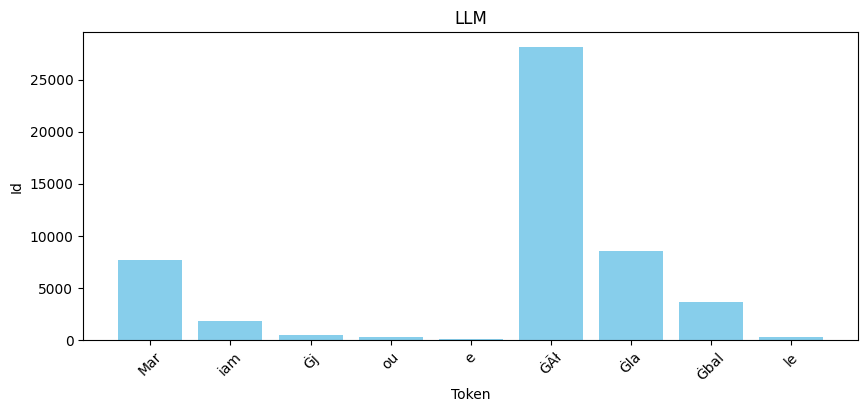

In [ ]:
text = "Mariam joue à la balle"  # fournir une phrase de votre choix
if text is None:
    raise ValueError("Définissez la variable `text` avec une courte phrase.")

tokens = tokenizer.tokenize(text)    # tokenize l'entrée
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # convertir en IDs

print(f"Texte original : {text}")
print(f"Tokens : {tokens}")
print(f"IDs des tokens : {token_ids}")

x_label = "Token"  #  étiquette pour l'axe des x
y_label = "Id"     # étiquette pour l'axe des y
title = "LLM"      #  titre du graphique

if None in (x_label, y_label, title):
    raise ValueError("Définissez x_label, y_label et title avant de tracer.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

##  Exercice 3 · IDs des tokens et préfixes spéciaux

In [ ]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Exécutez l'Exercice 2 pour définir d'abord `tokens` et `token_ids`.")

print("\nCorrespondance des tokens et de leurs IDs :")
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}' -> ID: {token_id}")


Correspondance des tokens et de leurs IDs :
Token: 'Mar' -> ID: 7676
Token: 'iam' -> ID: 1789
Token: 'Ġj' -> ID: 474
Token: 'ou' -> ID: 280
Token: 'e' -> ID: 68
Token: 'ĠÃł' -> ID: 28141
Token: 'Ġla' -> ID: 8591
Token: 'Ġbal' -> ID: 3652
Token: 'le' -> ID: 293


Le préfixe `Ġ` (représenté par un "G" majuscule ou un "G" barré dans certains environnements) est une caractéristique importante des tokeniseurs basés sur Byte Pair Encoding (BPE), comme celui utilisé par GPT-2.

Il indique la **présence d'un espace avant le token**.

Voici pourquoi c'est important et ce que cela signifie :

1.  **Distinction des mots** : Le tokeniseur ne supprime pas les espaces avant de tokeniser. Au lieu de cela, il les intègre dans certains tokens. Par exemple, si vous avez la phrase "Bonjour le monde", elle pourrait être tokenisée comme `['Bon', 'jour', 'Ġle', 'Ġmonde']`. Ici, `Ġle` signifie " espace + le" et `Ġmonde` signifie " espace + monde". Sans ce préfixe, le modèle ne saurait pas où se trouvent les limites des mots basées sur les espaces.

2.  **Reconstruction du texte** : Lorsque le modèle génère des tokens, le préfixe `Ġ` permet de savoir s'il faut ajouter un espace avant de joindre le token au texte précédent. C'est essentiel pour reconstruire le texte original avec la bonne ponctuation et les bons espaces.

3.  **Flexibilité de tokenisation** : Cela permet également au tokeniseur de gérer des sous-mots sans espace, comme la division de "running" en `['run', 'ning']`. Si `ning` avait un `Ġ` devant, cela signifierait " espace + ning", ce qui serait incorrect dans ce contexte.

En résumé, le `Ġ` est un indicateur visuel et fonctionnel qui aide le tokeniseur à gérer les espaces et à reconstruire le texte de manière cohérente, même lorsque les mots sont décomposés en sous-unités.

**texte en gras**##  Exercice 4 · Générer un texte simple

Créez un nouveau prompt, exécutez le générateur et observez comment le modèle étend votre phrase token par token.

In [ ]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "Je valide"  # TODO: écrivez un tout nouveau prompt
if input_text is None:
    raise ValueError("Définissez `input_text` avant de générer.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: ajustez si vous voulez des sorties plus longues/plus courtes
    "temperature": 0.8,    # TODO: ajustez la température d'échantillonnage
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: appelez le générateur
output_text = output_ids[0]["generated_text"]     # TODO: extrayez la chaîne de texte

print(f"Entrée : {input_text}")
print(f"Sortie générée : {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_p', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Entrée : Je valide
Sortie générée : Je valide, you are on a mission to prove yourself to the world.


> **Point d'apprentissage**
> Comparez la continuation générée avec vos attentes. Quels paramètres (température, nombre maximal de tokens) changent le plus le style ?

Voici un résumé qui peut vous aider à décider comment ajuster ces paramètres :

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)